# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [6]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [7]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

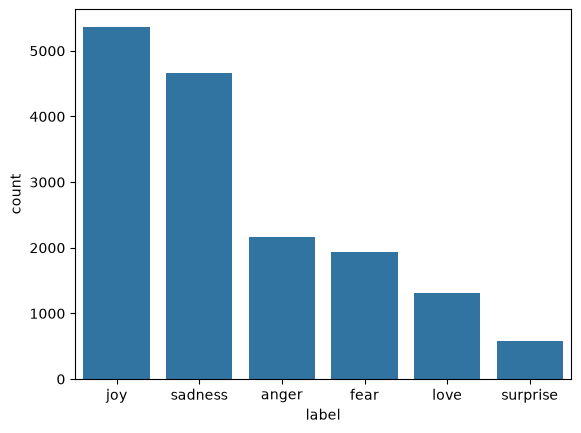

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [9]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.1529 - loss: 2.0646 - val_accuracy: 0.0870 - val_loss: 1.8161
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1431 - loss: 1.8991 - val_accuracy: 0.0840 - val_loss: 1.8053
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1292 - loss: 1.8333 - val_accuracy: 0.0490 - val_loss: 1.8024
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1316 - loss: 1.8070 - val_accuracy: 0.1250 - val_loss: 1.7688
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1341 - loss: 1.8019 - val_accuracy: 0.0450 - val_loss: 1.8072
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1317 - loss: 1.8001 - val_accuracy: 0.1410 - val_loss: 1.7853
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1547 - loss: 1.8003 - val_accuracy: 0.3235 - val_loss: 1.7826
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1250 - loss: 1.7688
RNN Loss: 1.768785595893

### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [15]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.1574 - loss: 1.7952 - val_accuracy: 0.3205 - val_loss: 1.7926
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.1401 - loss: 1.7938 - val_accuracy: 0.0330 - val_loss: 1.8105
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1504 - loss: 1.7935 - val_accuracy: 0.0350 - val_loss: 1.8103
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1401 - loss: 1.7872 - val_accuracy: 0.2765 - val_loss: 1.7772
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1681 - loss: 1.7679 - val_accuracy: 0.1525 - val_loss: 1.7911
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.2276 - loss: 1.6622 - val_accuracy: 0.2075 - val_loss: 1.7132
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3825 - loss: 1.3770 - val_accuracy: 0.4095 - val_loss: 1.4872
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7279 - loss: 0.7518 - 

### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [16]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.1494 - loss: 1.7964 - val_accuracy: 0.3445 - val_loss: 1.7828
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1523 - loss: 1.7956 - val_accuracy: 0.3435 - val_loss: 1.7692
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1449 - loss: 1.7946 - val_accuracy: 0.2895 - val_loss: 1.7712
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1611 - loss: 1.7930 - val_accuracy: 0.0345 - val_loss: 1.8132
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1574 - loss: 1.7914 - val_accuracy: 0.1415 - val_loss: 1.8009
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3435 - loss: 1.7692
GRU Loss: 1.7692028284072876
GRU Accuracy: 0.3434999883174896


### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [17]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.285658,0.9110
2,GRU,1.769203,0.3435
0,RNN,1.768786,0.1250


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [18]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train & Evaluate Advanced Bidirectional GRU

In [28]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/20


400/400 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9403 - loss: 0.1766 - val_accuracy: 0.9422 - val_loss: 0.1586
Epoch 2/20
155/400 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.9512 - loss: 0.1238

KeyboardInterrupt: 

In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9110 - loss: 0.2202
BiGRU Loss: 0.22024297714233398
BiGRU Accuracy: 0.9110000133514404


## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [21]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


<Axes: >

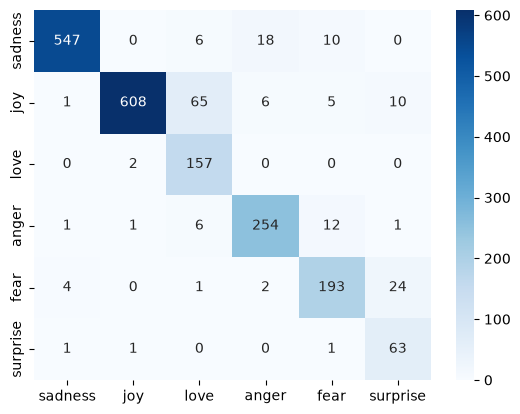

In [22]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [23]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [25]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pickle'), 'wb') as file:
  pickle.dump(tokenizer, file)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(test_label, BiGRU_predictions, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.99      0.94      0.96       581
         joy       0.99      0.87      0.93       695
        love       0.67      0.99      0.80       159
       anger       0.91      0.92      0.92       275
        fear       0.87      0.86      0.87       224
    surprise       0.64      0.95      0.77        66

    accuracy                           0.91      2000
   macro avg       0.85      0.92      0.87      2000
weighted avg       0.93      0.91      0.92      2000



In [27]:
for i, name in enumerate(label_names):
    print(name, class_weight_dict[i])

sadness 0.5715102157451064
joy 0.49732686808404825
love 2.044989775051125
anger 1.2351397251814111
fear 1.3766993632765445
surprise 4.662004662004662
